# VoiceBank Speech Enhancement: Definition – UNet for Log-Mel Spectrogram Enhancement

**Project Goal**: Build a deep learning model to denoise speech using the VoiceBank-DEMAND dataset.

This notebook defines a UNet-style model for speech enhancement, with log-Mel spectrograms as input.

- Input:  (B, 1, M, T) - Noisy log-Mel
- Output: (B, 1, M, T) - Cleaned log-Mel

**Notebook Overview**:
- Define a FeatureDataset class.
- Create DataLoaders for training and validation.
- UNet model takes a log-Mel spectrogram of noisy speech as input.
- Outputs a cleaned version with the same shape.
- Learns a direct mapping from noisy to clean.

**Next Steps**:
- Train the neural network model
- Evaluate and visualize performance

**Author**: Jo  
**Date**: Aug 2025


In [1]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
from tqdm import tqdm
import pickle
import torch.nn as nn


data_root = "/kaggle/input/voicebank-demand"

## Feature dataset

In [2]:
class FeatureDataset(Dataset):
    """
    Enhanced dataset class for loading precomputed features
    Supports multiple feature types and data validation
    """
    
    def __init__(self, feature_dir, file_list, feature_type='logmel', 
                 normalize=True, augment=False, augment_prob=0.3):
        """
        Args:
            feature_dir (str): Directory containing features
            file_list (list): List of file IDs (without extensions)
            feature_type (str): Type of features ('logmel', 'stft', 'mfcc')
            normalize (bool): Apply normalization
            augment (bool): Apply data augmentation
            augment_prob (float): Probability of applying augmentation
        """
        self.feature_dir = feature_dir
        self.file_list = file_list
        self.feature_type = feature_type
        self.normalize = normalize
        self.augment = augment
        self.augment_prob = augment_prob
        
        # Validate dataset
        self._validate_dataset()
        
        # Compute normalization statistics if needed
        if normalize:
            self.stats = self._compute_normalization_stats()
    
    def _validate_dataset(self):
        """Validate that all required files exist"""
        missing_files = []
        
        for file_id in self.file_list:
            noisy_path = os.path.join(self.feature_dir, self.feature_type, 
                                    'noisy', f'{file_id}.npy')
            clean_path = os.path.join(self.feature_dir, self.feature_type, 
                                    'clean', f'{file_id}.npy')
            
            if not os.path.exists(noisy_path):
                missing_files.append(f"noisy/{file_id}.npy")
            if not os.path.exists(clean_path):
                missing_files.append(f"clean/{file_id}.npy")
        
        if missing_files:
            print(f"Warning: {len(missing_files)} missing files found")
            if len(missing_files) < 10:
                print("Missing files:", missing_files)
        
        # Remove files that don't have both noisy and clean versions
        valid_files = []
        for file_id in self.file_list:
            noisy_path = os.path.join(self.feature_dir, self.feature_type, 
                                    'noisy', f'{file_id}.npy')
            clean_path = os.path.join(self.feature_dir, self.feature_type, 
                                    'clean', f'{file_id}.npy')
            
            if os.path.exists(noisy_path) and os.path.exists(clean_path):
                valid_files.append(file_id)
        
        removed_count = len(self.file_list) - len(valid_files)
        if removed_count > 0:
            print(f"Removed {removed_count} invalid files")
        
        self.file_list = valid_files
        print(f"Validated dataset: {len(self.file_list)} valid samples")
    
    def _compute_normalization_stats(self, max_samples=500):
        """Compute normalization statistics from a subset of data"""
        stats_file = os.path.join(self.feature_type, 
                                 f'norm_stats_{self.feature_type}.pkl')
        #stats_file = os.path.join(self.feature_dir, self.feature_type, 
                                 #f'final_stats.pkl')
        
        # Load cached stats if available
        if os.path.exists(stats_file):
            print(os.path.exists(stats_file))
            try:
                with open(stats_file, 'rb') as f:
                    stats = pickle.load(f)
                print(f"Loaded normalization stats from cache")
                return stats
            except:
                print("Failed to load cached stats, recomputing...")
        
        print("Computing normalization statistics...")
        
        # Sample files for statistics
        sample_files = random.sample(self.file_list, 
                                   min(max_samples, len(self.file_list)))
        
        all_noisy = []
        all_clean = []
        
        for file_id in tqdm(sample_files, desc="Computing stats"):
            try:
                noisy_feat = self._load_feature(file_id, 'noisy')
                clean_feat = self._load_feature(file_id, 'clean')
                
                all_noisy.append(noisy_feat.flatten())
                all_clean.append(clean_feat.flatten())
            except:
                continue
        
        # Compute statistics
        all_noisy = np.concatenate(all_noisy)
        all_clean = np.concatenate(all_clean)
        
        stats = {'noisy_mean': np.mean(all_noisy), 
                 'noisy_std': np.std(all_noisy), 
                 'clean_mean': np.mean(all_clean),
                 'clean_std': np.std(all_clean), 
                 'global_min': min(np.min(all_noisy), np.min(all_clean)), 
                 'global_max': max(np.max(all_noisy), np.max(all_clean))}
        
        # Cache the statistics
        os.makedirs(os.path.dirname(stats_file), exist_ok=True)
        with open(stats_file, 'wb') as f:
            pickle.dump(stats, f)
        
        print(f"Cached normalization stats")
        print(f"   Noisy: μ={stats['noisy_mean']:.3f}, σ={stats['noisy_std']:.3f}")
        print(f"   Clean: μ={stats['clean_mean']:.3f}, σ={stats['clean_std']:.3f}")
        
        return stats
    
    def _load_feature(self, file_id, split):
        """Load a single feature file"""
        file_path = os.path.join(self.feature_dir, self.feature_type, 
                               split, f'{file_id}.npy')
        return np.load(file_path)
    
    def _normalize_feature(self, feature, split='noisy'):
        """Normalize feature using computed statistics"""
        if not self.normalize:
            return feature
        
        mean = self.stats[f'{split}_mean']
        std = self.stats[f'{split}_std']
        
        return (feature - mean) / (std + 1e-8)
    
    def _augment_feature(self, noisy_feat, clean_feat):
        """Apply feature-space augmentation"""
        if not self.augment or random.random() > self.augment_prob:
            return noisy_feat, clean_feat
        
        # Feature-space augmentations
        aug_type = random.choice(['noise', 'scale', 'shift', 'dropout'])
        
        if aug_type == 'noise':
            # Add noise to noisy features only
            noise_std = 0.05 * np.std(noisy_feat)
            noise = np.random.normal(0, noise_std, noisy_feat.shape)
            noisy_feat = noisy_feat + noise
            
        elif aug_type == 'scale':
            # Random scaling
            scale = random.uniform(0.9, 1.1)
            noisy_feat = noisy_feat * scale
            clean_feat = clean_feat * scale
            
        elif aug_type == 'shift':
            # Random DC shift
            shift = random.uniform(-0.1, 0.1)
            noisy_feat = noisy_feat + shift
            clean_feat = clean_feat + shift
            
        elif aug_type == 'dropout':
            # Feature dropout (set random features to 0)
            dropout_prob = 0.05
            mask = np.random.binomial(1, 1-dropout_prob, noisy_feat.shape)
            noisy_feat = noisy_feat * mask
        
        return noisy_feat, clean_feat
    
    def __len__(self):
        return len(self.file_list)
    
    def __getitem__(self, idx):
        try:
            file_id = self.file_list[idx]
            
            # Load features
            noisy_feat = self._load_feature(file_id, 'noisy')
            clean_feat = self._load_feature(file_id, 'clean')
            
            # Apply augmentation
            noisy_feat, clean_feat = self._augment_feature(noisy_feat, clean_feat)
            
            # Normalize
            noisy_feat = self._normalize_feature(noisy_feat, 'noisy')
            clean_feat = self._normalize_feature(clean_feat, 'clean')
            
            # Convert to tensors
            noisy_tensor = torch.tensor(noisy_feat, dtype=torch.float32)
            clean_tensor = torch.tensor(clean_feat, dtype=torch.float32)
            
            return noisy_tensor, clean_tensor
            
        except Exception as e:
            print(f"Error loading {file_id}: {e}")
            # Return a zero tensor in case of error
            dummy_shape = (1, 64, 126)  # Default shape for logmel
            return (torch.zeros(dummy_shape, dtype=torch.float32),
                    torch.zeros(dummy_shape, dtype=torch.float32))

## functions to create feature datasets

In [3]:
def get_file_list(feature_dir, feature_type='logmel'):
    """Get list of available feature files"""
    noisy_dir = os.path.join(feature_dir, feature_type, 'noisy')
    
    if not os.path.exists(noisy_dir):
        raise FileNotFoundError(f"Feature directory not found: {noisy_dir}")
    
    files = [f.replace('.npy', '') for f in os.listdir(noisy_dir) 
             if f.endswith('.npy')]
    
    return sorted(files)

def create_datasets(feature_dir, feature_type='logmel', val_ratio=0.1, 
                   test_ratio=0.1, random_state=42, normalize=True, 
                   augment_train=True):
    """
    Create train, validation, and test datasets
    
    Args:
        feature_dir (str): Directory containing features
        feature_type (str): Type of features to load
        val_ratio (float): Validation split ratio
        test_ratio (float): Test split ratio
        random_state (int): Random seed
        normalize (bool): Apply normalization
        augment_train (bool): Apply augmentation to training set
    
    Returns:
        tuple: (train_dataset, val_dataset, test_dataset)
    """
    
    print(f"Creating datasets for {feature_type} features...")
    
    # Get file list
    file_list = get_file_list(feature_dir, feature_type)
    print(f"Found {len(file_list)} feature files")
    
    # Split into train/val/test
    train_files, temp_files = train_test_split(
        file_list, test_size=(val_ratio + test_ratio), 
        random_state=random_state
    )
    
    # Split temp into val and test
    val_files, test_files = train_test_split(
        temp_files, test_size=(test_ratio / (val_ratio + test_ratio)), 
        random_state=random_state
    )
    
    print(f"Split: {len(train_files)} train, {len(val_files)} val, {len(test_files)} test")
    
    # Create datasets
    train_dataset = FeatureDataset(
        feature_dir, train_files, feature_type, 
        normalize=normalize, augment=augment_train, augment_prob=0.3
    )
    
    val_dataset = FeatureDataset(
        feature_dir, val_files, feature_type, 
        normalize=normalize, augment=False
    )
    
    test_dataset = FeatureDataset(
        feature_dir, test_files, feature_type, 
        normalize=normalize, augment=False
    )
    
    return train_dataset, val_dataset, test_dataset

## function to create dataloaders

In [4]:
def create_dataloaders(feature_dir, feature_type='logmel', batch_size=16, 
                      val_ratio=0.1, test_ratio=0.1, random_state=42, 
                      num_workers=2, normalize=True, augment_train=True):
    """
    Create DataLoaders for training, validation, and testing
    
    Args:
        feature_dir (str): Directory containing features
        feature_type (str): Type of features to load
        batch_size (int): Batch size for DataLoaders
        val_ratio (float): Validation split ratio
        test_ratio (float): Test split ratio
        random_state (int): Random seed
        num_workers (int): Number of workers for DataLoader
        normalize (bool): Apply normalization
        augment_train (bool): Apply augmentation to training set
    
    Returns:
        tuple: (train_loader, val_loader, test_loader)
    """
    
    # Create datasets
    train_dataset, val_dataset, test_dataset = create_datasets(
        feature_dir, feature_type, val_ratio, test_ratio, 
        random_state, normalize, augment_train
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, 
        num_workers=num_workers, pin_memory=True, drop_last=True
    )
    
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False, 
        num_workers=num_workers, pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, 
        num_workers=num_workers, pin_memory=True
    )
    
    print(f"Created DataLoaders:")
    print(f"   Train: {len(train_loader)} batches ({len(train_dataset)} samples)")
    print(f"   Val:   {len(val_loader)} batches ({len(val_dataset)} samples)")
    print(f"   Test:  {len(test_loader)} batches ({len(test_dataset)} samples)")
    
    return train_loader, val_loader, test_loader

## Visualisation

In [5]:
def visualise_batch(dataloader, feature_type='logmel', batch_idx=0, num_samples=4):
    """Visualise a batch of data"""
    
    # Get a batch
    for i, (noisy_batch, clean_batch) in enumerate(dataloader):
        if i == batch_idx:
            break
    
    # Convert to numpy and select samples to show
    noisy_np = noisy_batch.numpy()
    clean_np = clean_batch.numpy()
    
    num_samples = min(num_samples, noisy_np.shape[0])
    
    fig, axes = plt.subplots(2, num_samples, figsize=(4*num_samples, 8))
    if num_samples == 1:
        axes = axes.reshape(-1, 1)
    
    for i in range(num_samples):
        # Remove channel dimension for visualization
        noisy_spec = np.squeeze(noisy_np[i])
        clean_spec = np.squeeze(clean_np[i])

        vmin = min(noisy_spec.min(), clean_spec.min())
        vmax = max(noisy_spec.max(), clean_spec.max())


        
        # Plot noisy
        im1 = axes[0, i].imshow(noisy_spec, aspect = 'auto', vmin=vmin, vmax=vmax, 
                               cmap='viridis')
        axes[0, i].set_title(f'Noisy {feature_type} {i+1}')
        axes[0, i].set_xlabel('Time Frames')
        if feature_type == 'logmel':
            axes[0, i].set_ylabel('Mel Bins')
        elif feature_type == 'stft':
            axes[0, i].set_ylabel('Frequency Bins')
        
        # Plot clean
        #im2 = axes[1, i].imshow(clean_spec, aspect='auto', origin='lower', 
                               #cmap='viridis')
        im2 = axes[1, i].imshow(clean_spec, aspect = 'auto', vmin=vmin, vmax=vmax, 
                               cmap='viridis')
        axes[1, i].set_title(f'Clean {feature_type} {i+1}')
        axes[1, i].set_xlabel('Time Frames')
        if feature_type == 'logmel':
            axes[1, i].set_ylabel('Mel Bins')
        elif feature_type == 'stft':
            axes[1, i].set_ylabel('Frequency Bins')
        
        # Add colorbars
        plt.colorbar(im1, ax=axes[0, i], shrink=0.8)
        plt.colorbar(im2, ax=axes[1, i], shrink=0.8)
    
    plt.tight_layout()
    plt.show()
    
    # Print batch statistics
    print(f"Batch Statistics:")
    print(f"   Batch shape: {noisy_batch.shape}")
    print(f"   Noisy range: [{noisy_batch.min():.3f}, {noisy_batch.max():.3f}]")
    print(f"   Clean range: [{clean_batch.min():.3f}, {clean_batch.max():.3f}]")
    print(f"   Mean difference: {torch.mean(torch.abs(clean_batch - noisy_batch)):.3f}")


## Analyse dataset

In [6]:
def analyse_dataset_distribution(dataloaders, feature_type='logmel'):
    """Analyse the distribution of features across train/val/test sets"""
    
    train_loader, val_loader, test_loader = dataloaders
    
    print(f"Analysing {feature_type} feature distributions...")
    
    def collect_stats(loader, name):
        all_noisy = []
        all_clean = []
        
        for noisy_batch, clean_batch in tqdm(loader, desc=f"Analyzing {name}"):
            all_noisy.append(noisy_batch.flatten())
            all_clean.append(clean_batch.flatten())
        
        all_noisy = torch.cat(all_noisy)
        all_clean = torch.cat(all_clean)
        
        return {
            'noisy_mean': all_noisy.mean().item(),
            'noisy_std': all_noisy.std().item(),
            'clean_mean': all_clean.mean().item(), 
            'clean_std': all_clean.std().item(),
            'noisy_min': all_noisy.min().item(),
            'noisy_max': all_noisy.max().item(),
            'clean_min': all_clean.min().item(),
            'clean_max': all_clean.max().item()
        }
    
    # Collect statistics for each split
    train_stats = collect_stats(train_loader, "train")
    val_stats = collect_stats(val_loader, "validation") 
    test_stats = collect_stats(test_loader, "test")
    
    # Print comparison
    print("\nDataset Distribution Analysis:")
    print("=" * 80)
    print(f"{'Split':<10} {'Type':<6} {'Mean':<8} {'Std':<8} {'Min':<8} {'Max':<8}")
    print("-" * 80)
    
    for split, stats in [('Train', train_stats), ('Val', val_stats), ('Test', test_stats)]:
        for signal_type in ['noisy', 'clean']:
            print(f"{split:<10} {signal_type:<6} "
                  f"{stats[f'{signal_type}_mean']:<8.3f} "
                  f"{stats[f'{signal_type}_std']:<8.3f} "
                  f"{stats[f'{signal_type}_min']:<8.3f} "
                  f"{stats[f'{signal_type}_max']:<8.3f}")
    
    return train_stats, val_stats, test_stats

## Define UNet model

In [7]:
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.encoder1 = ConvBlock(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.encoder2 = ConvBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        
        self.bottleneck = ConvBlock(64, 128)
        
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder2 = ConvBlock(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.decoder1 = ConvBlock(64, 32)
        
        self.output_layer = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        # x: (B, 1, M, T)
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool1(enc1))
        bottleneck = self.bottleneck(self.pool2(enc2))

        up2 = self.up2(bottleneck)
        dec2 = self.decoder2(torch.cat([up2, enc2], dim=1))
        up1 = self.up1(dec2)
        dec1 = self.decoder1(torch.cat([up1, enc1], dim=1))

        out = self.output_layer(dec1)
        return out


## data consistency

In [8]:
def check_data_consistency(dataloaders):
    """Check for data consistency issues"""
    
    train_loader, val_loader, test_loader = dataloaders
    
    print("Checking data consistency...")
    
    issues = []
    
    # Check shapes consistency
    shapes_train = set()
    shapes_val = set()
    shapes_test = set()
    
    for i, (noisy, clean) in enumerate(train_loader):
        shapes_train.add(noisy.shape[1:])  # Exclude batch dimension
        if i >= 5:  # Check first few batches only
            break
    
    for i, (noisy, clean) in enumerate(val_loader):
        shapes_val.add(noisy.shape[1:])
        if i >= 5:
            break
    
    for i, (noisy, clean) in enumerate(test_loader):
        shapes_test.add(noisy.shape[1:])
        if i >= 5:
            break
    
    if len(shapes_train) > 1:
        issues.append(f"Inconsistent shapes in training set: {shapes_train}")
    if len(shapes_val) > 1:
        issues.append(f"Inconsistent shapes in validation set: {shapes_val}")
    if len(shapes_test) > 1:
        issues.append(f"Inconsistent shapes in test set: {shapes_test}")
    
    # Check for NaN or Inf values
    def check_batch_validity(loader, name):
        nan_count = 0
        inf_count = 0
        
        for i, (noisy, clean) in enumerate(loader):
            if torch.isnan(noisy).any() or torch.isnan(clean).any():
                nan_count += 1
            if torch.isinf(noisy).any() or torch.isinf(clean).any():
                inf_count += 1
            
            if i >= 10:  # Check first 10 batches
                break
        
        if nan_count > 0:
            issues.append(f"NaN values found in {nan_count} batches of {name} set")
        if inf_count > 0:
            issues.append(f"Inf values found in {inf_count} batches of {name} set")
    
    check_batch_validity(train_loader, "training")
    check_batch_validity(val_loader, "validation")
    check_batch_validity(test_loader, "test")
    
    if issues:
        print("Issues found:")
        for issue in issues:
            print(f"   - {issue}")
        return False
    else:
        print("No consistency issues found")
        return True


In [9]:
def diagnose_sample_differences(train_loader, num_samples=10):
    """Check if noisy and clean samples are actually different"""
    
    print("🔍 Diagnosing Sample Differences")
    print("=" * 50)
    
    issues = []
    
    for batch_idx, (noisy_batch, clean_batch) in enumerate(train_loader):
        if batch_idx >= num_samples:
            break
        
        for i in range(noisy_batch.shape[0]):
            noisy = noisy_batch[i].numpy()
            clean = clean_batch[i].numpy()
            
            # Calculate difference metrics
            absolute_diff = np.abs(noisy - clean)
            mean_diff = np.mean(absolute_diff)
            max_diff = np.max(absolute_diff)
            
            # Calculate correlation
            corr = np.corrcoef(noisy.flatten(), clean.flatten())[0, 1]
            
            # Calculate SNR in feature domain
            signal_power = np.mean(clean ** 2)
            noise_power = np.mean((noisy - clean) ** 2)
            snr = 10 * np.log10(signal_power / (noise_power + 1e-10)) if noise_power > 0 else 100
            
            sample_id = batch_idx * train_loader.batch_size + i
            
            
            # Flag suspicious samples
            if mean_diff < 0.1 or corr > 0.99:
                issues.append({
                    'sample_id': sample_id,
                    'mean_diff': mean_diff,
                    'correlation': corr,
                    'snr': snr,
                    'issue': 'Nearly identical'
                })
                print(f"\nSample {sample_id}:")
                print(f"  Mean Diff: {mean_diff:.4f}")
                print(f"  Max Diff:  {max_diff:.4f}")
                print(f"  Correlation: {corr:.4f}")
                print(f"  SNR: {snr:.2f} dB")
            
                print(f"WARNING: Noisy and clean are nearly identical!")
            
            if snr > 30:
                issues.append({
                    'sample_id': sample_id,
                    'mean_diff': mean_diff,
                    'correlation': corr,
                    'snr': snr,
                    'issue': 'Very high SNR'
                })

                print(f"\nSample {sample_id}:")
                print(f"  Mean Diff: {mean_diff:.4f}")
                print(f"  Max Diff:  {max_diff:.4f}")
                print(f"  Correlation: {corr:.4f}")
                print(f"  SNR: {snr:.2f} dB")
            
                print(f"WARNING: Very high SNR - minimal noise!")
    
    # Summary
    print(f"\n Summary:")
    print(f"  Total samples checked: {num_samples * train_loader.batch_size}")
    print(f"  Suspicious samples: {len(issues)}")
    
    if issues:
        print(f"\n Issues found:")
        for issue in issues[:5]:  # Show first 5
            print(f"    Sample {issue['sample_id']}: {issue['issue']} "
                  f"(corr={issue['correlation']:.3f}, SNR={issue['snr']:.1f}dB)")
    
    return issues

## Testing

Setting up enhanced data pipeline for logmel features
Creating datasets for logmel features...
Found 1000 feature files
Split: 800 train, 100 val, 100 test
Validated dataset: 800 valid samples
Computing normalization statistics...


Computing stats: 100%|██████████| 500/500 [00:04<00:00, 110.75it/s]


Cached normalization stats
   Noisy: μ=-41.323, σ=16.596
   Clean: μ=-53.534, σ=20.949
Validated dataset: 100 valid samples
True
Loaded normalization stats from cache
Validated dataset: 100 valid samples
True
Loaded normalization stats from cache
Created DataLoaders:
   Train: 50 batches (800 samples)
   Val:   7 batches (100 samples)
   Test:  7 batches (100 samples)

Visualising training batch...


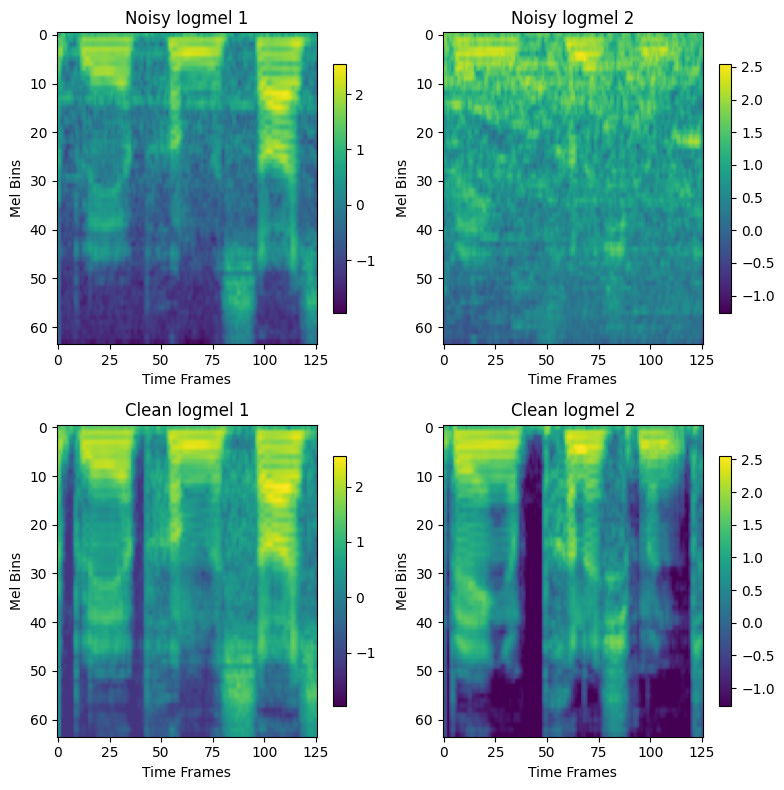

Batch Statistics:
   Batch shape: torch.Size([16, 1, 64, 126])
   Noisy range: [-2.376, 2.510]
   Clean range: [-1.633, 2.555]
   Mean difference: 0.580
🔍 Diagnosing Sample Differences

Sample 38:
  Mean Diff: 0.6187
  Max Diff:  1.1619
  Correlation: 0.9928
  SNR: 3.72 dB

 Summary:
  Total samples checked: 80
  Suspicious samples: 1

 Issues found:
    Sample 38: Nearly identical (corr=0.993, SNR=3.7dB)

Checking data consistency...
Checking data consistency...
No consistency issues found

Analysing distributions...
Analysing logmel feature distributions...


Analyzing test: 100%|██████████| 7/7 [00:00<00:00, 38.21it/s]


Dataset Distribution Analysis:
Split      Type   Mean     Std      Min      Max     
--------------------------------------------------------------------------------
Train      noisy  0.011    1.005    -2.806   2.636   
Train      clean  -0.016   1.004    -1.640   2.560   
Val        noisy  0.031    1.003    -2.330   2.490   
Val        clean  -0.010   1.007    -1.263   2.555   
Test       noisy  0.086    0.935    -2.330   2.490   
Test       clean  -0.050   0.998    -1.263   2.555   

Data pipeline setup complete!
Ready for training with:
   - Feature type: logmel
   - Batch size: 16
   - Normalization: Enabled
   - Augmentation: Enabled for training


In [10]:
if __name__ == "__main__":
    # Configuration
    feature_dir = "/kaggle/input/voicebank-features/voicebank_features"
    # For local testing: feature_dir = "voicebank_features"
    
    feature_type = 'logmel'  # Can be 'logmel', 'stft', or 'mfcc'
    batch_size = 16
    
    print(f"Setting up enhanced data pipeline for {feature_type} features")
    
    # Check if feature directory exists
    feature_path = os.path.join(feature_dir, feature_type)
    if not os.path.exists(feature_path):
        print(f"Feature directory not found: {feature_path}")
        print("Please run the feature extraction notebook first!")
        exit(1)
    
    # Create data loaders
    try:
        train_loader, val_loader, test_loader = create_dataloaders(
            feature_dir=feature_dir,
            feature_type=feature_type,
            batch_size=batch_size,
            val_ratio=0.1,
            test_ratio=0.1,
            random_state=42,
            num_workers=0,  # Set to 0 for Kaggle
            normalize=True,
            augment_train=True
        )
        
        # Visualise batch
        print("\nVisualising training batch...")
        visualise_batch(train_loader, feature_type, num_samples=2)

        # Diagnostic tool
        issues = diagnose_sample_differences(train_loader, num_samples=5)
        
        # Check data consistency
        print("\nChecking data consistency...")
        consistency_ok = check_data_consistency([train_loader, val_loader, test_loader])
        
        # Analyse distributions (optional - can be time consuming)
        print("\nAnalysing distributions...")
        train_stats, val_stats, test_stats = analyse_dataset_distribution(
           [train_loader, val_loader, test_loader], feature_type
         )
        
        print("\nData pipeline setup complete!")
        print(f"Ready for training with:")
        print(f"   - Feature type: {feature_type}")
        print(f"   - Batch size: {batch_size}")
        print(f"   - Normalization: Enabled")
        print(f"   - Augmentation: Enabled for training")
        
    except Exception as e:
        print(f"Error setting up data pipeline: {e}")
        raise